<a href="https://colab.research.google.com/github/prameesha04/Agentic_AI_Internship/blob/main/RNN_PT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from tqdm import tqdm

In [3]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(SingleRNN, self).__init__()

        self.Wx = torch.randn(n_inputs, n_neurons) # 4 X 1
        self.Wy = torch.randn(n_neurons, n_neurons) # 1 X 1

        self.b = torch.zeros(1, n_neurons) # 1 X 4

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # 4 X 1

        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) +
                             torch.mm(X1, self.Wx) + self.b) # 4 X 1

        return self.Y0, self.Y1

In [4]:
N_INPUT = 4
N_NEURONS = 1

X0_batch = torch.tensor([[0,1,2,0], [3,4,5,0],
                         [6,7,8,0], [9,0,1,0]],
                        dtype = torch.float) #t=0 => 4 X 4

X1_batch = torch.tensor([[9,8,7,0], [0,0,0,0],
                         [6,5,4,0], [3,2,1,0]],
                        dtype = torch.float) #t=1 => 4 X 4

model = SingleRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

In [5]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(BasicRNN, self).__init__()

        self.Wx = torch.randn(n_inputs, n_neurons) # n_inputs X n_neurons
        self.Wy = torch.randn(n_neurons, n_neurons) # n_neurons X n_neurons

        self.b = torch.zeros(1, n_neurons) # 1 X n_neurons

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # batch_size X n_neurons

        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) +
                             torch.mm(X1, self.Wx) + self.b) # batch_size X n_neurons

        return self.Y0, self.Y1

In [6]:
N_INPUT = 3 # number of features in input
N_NEURONS = 5 # number of units in layer

X0_batch = torch.tensor([[0,1,2], [3,4,5],
                         [6,7,8], [9,0,1]],
                        dtype = torch.float) # #t=0 => 4 X 3

X1_batch = torch.tensor([[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]],
                        dtype = torch.float) # #t=1 => 4 X 3

model = BasicRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

In [7]:
print(Y1_val)

tensor([[ 1.0000, -1.0000, -1.0000,  0.7521, -1.0000],
        [ 0.6516,  0.4749,  0.7280, -0.2792,  0.9636],
        [ 0.9981, -1.0000, -0.9996, -0.4272, -1.0000],
        [-0.6981, -0.9999, -0.9996, -0.9889, -1.0000]])


In [8]:
rnn = nn.RNNCell(3, 5) # n_input X n_neurons

X_batch = torch.tensor([[[0,1,2], [3,4,5],
                         [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]]
                       ], dtype = torch.float) # X0 and X1

hx = torch.randn(4, 5) # m X n_neurons
output = []
# for each time step
for i in range(2):
    hx = rnn(X_batch[i], hx)
    output.append(hx)
print(output)

[tensor([[ 0.7790,  0.5524, -0.4838, -0.3110,  0.4007],
        [ 0.7702,  0.6317, -0.8830, -0.8012,  0.4061],
        [ 0.9394,  0.3502, -0.9294, -0.9919, -0.8590],
        [ 0.7221, -0.9867, -0.9169, -0.9980,  0.5957]],
       grad_fn=<TanhBackward0>), tensor([[ 0.9532, -0.8370, -0.9902, -0.9997, -0.9133],
        [ 0.8105,  0.0024, -0.7282, -0.8838,  0.4103],
        [ 0.8799, -0.8984, -0.9855, -0.9962, -0.4291],
        [ 0.6714, -0.3090, -0.8757, -0.9723, -0.6548]],
       grad_fn=<TanhBackward0>)]


In [9]:
class CleanBasicRNN(nn.Module):
    def __init__(self, batch_size, n_inputs, n_neurons):
        super(CleanBasicRNN, self).__init__()
        self.rnn = nn.RNNCell(n_inputs, n_neurons)
        self.hx = torch.randn(batch_size, n_neurons) # initialize hidden state

    def forward(self, X):
        output = []
        # for each time step
        for i in range(2):
            self.hx = self.rnn(X[i], self.hx)
            output.append(self.hx)
        return output, self.hx

In [10]:
FIXED_BATCH_SIZE = 4
N_INPUT = 3
N_NEURONS = 5

X_batch = torch.tensor([[[0,1,2], [3,4,5], [6,7,8], [9,0,1]], [[9,8,7], [0,0,0], [6,5,4], [3,2,1]]], dtype=torch.float)
model = CleanBasicRNN(FIXED_BATCH_SIZE, N_INPUT, N_NEURONS)
output_val, states_val = model(X_batch)
print(output_val)
print(states_val)

[tensor([[-0.9857,  0.4299, -0.9929, -0.3446,  0.2191],
        [ 0.4657,  0.9845, -0.6636, -0.0400,  0.9710],
        [ 0.5764,  0.9997, -0.9754,  0.3182,  0.9975],
        [ 0.4392,  0.9379, -0.9578, -0.2967, -0.8209]],
       grad_fn=<TanhBackward0>), tensor([[ 0.6007,  0.9999, -0.9879, -0.8833,  0.9947],
        [-0.2742,  0.4240, -0.1866,  0.0316, -0.2775],
        [ 0.6149,  0.9989, -0.6446, -0.6608,  0.8959],
        [ 0.6885,  0.9637, -0.4529,  0.0321,  0.3965]],
       grad_fn=<TanhBackward0>)]
tensor([[ 0.6007,  0.9999, -0.9879, -0.8833,  0.9947],
        [-0.2742,  0.4240, -0.1866,  0.0316, -0.2775],
        [ 0.6149,  0.9989, -0.6446, -0.6608,  0.8959],
        [ 0.6885,  0.9637, -0.4529,  0.0321,  0.3965]],
       grad_fn=<TanhBackward0>)


In [11]:
import torchvision
import torchvision.transforms as transforms

In [12]:
BATCH_SIZE = 64
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.29MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.80MB/s]


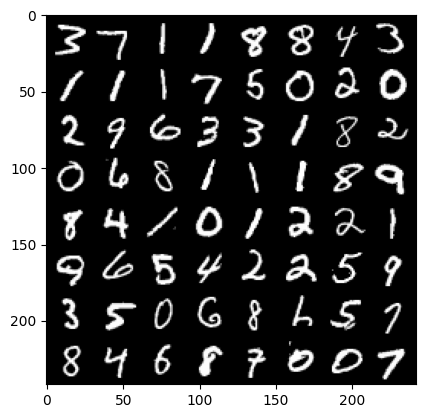

In [13]:
import matplotlib.pyplot as plt
import numpy as np
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

data_iter = iter(trainloader)
images, labels = next(data_iter)
imshow(torchvision.utils.make_grid(images))

In [14]:
N_STEPS = 28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPOCHS = 10

In [15]:
import torch.nn as nn

class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons,n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = 10

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)
        # Continuing from the __init__ method:

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self):
        # (num_layers, batch_size, n_neurons)
        return torch.zeros(1, self.batch_size, self.n_neurons)

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)

        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()

        # lstm_out => n_steps, batch_size, n_neurons (hidden states)
        # self.hidden => 1, batch_size, n_neurons (final state)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)

        out = self.FC(self.hidden)

        return out.view(-1, self.n_outputs) # batch_size X n_outputs

In [16]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28, 28))
print(logits[0:10])

tensor([[-0.0159,  0.0570, -0.0098, -0.0556, -0.0048,  0.0141,  0.0585, -0.0430,
         -0.0904, -0.0278],
        [-0.0123,  0.0427, -0.0339, -0.0086,  0.0233, -0.0084,  0.0402, -0.0655,
         -0.0642, -0.0326],
        [-0.0207,  0.0561, -0.0118, -0.0480, -0.0045,  0.0133,  0.0650, -0.0415,
         -0.0882, -0.0221],
        [-0.0200,  0.0646, -0.0058, -0.0428,  0.0009,  0.0030,  0.0797, -0.0453,
         -0.1005, -0.0275],
        [-0.0194,  0.0925, -0.0217, -0.0622,  0.0261,  0.0054,  0.0957, -0.0376,
         -0.1191, -0.0335],
        [-0.0172,  0.0581, -0.0137, -0.0487, -0.0015,  0.0141,  0.0597, -0.0428,
         -0.0853, -0.0248],
        [-0.0194,  0.0588, -0.0078, -0.0508, -0.0050,  0.0192,  0.0648, -0.0449,
         -0.0878, -0.0247],
        [ 0.0109,  0.0709, -0.0472, -0.0243,  0.0336,  0.0033,  0.0444, -0.0763,
         -0.0810, -0.0016],
        [-0.0112,  0.0659, -0.0075, -0.0591, -0.0062,  0.0172,  0.0704, -0.0494,
         -0.0968, -0.0299],
        [-0.0338,  

In [17]:
import torch.optim as optim
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def get_accuracy(logit, target, batch_size):
    '''Obtain accuracy for training round'''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects / batch_size
    return accuracy.item()

In [19]:
for epoch in range(N_EPOCHS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.7343 | Train Accuracy: 76.06
Epoch:  1 | Loss: 0.3246 | Train Accuracy: 90.67
Epoch:  2 | Loss: 0.2333 | Train Accuracy: 93.39
Epoch:  3 | Loss: 0.1972 | Train Accuracy: 94.37
Epoch:  4 | Loss: 0.1680 | Train Accuracy: 95.29
Epoch:  5 | Loss: 0.1543 | Train Accuracy: 95.65
Epoch:  6 | Loss: 0.1461 | Train Accuracy: 95.84
Epoch:  7 | Loss: 0.1408 | Train Accuracy: 96.09
Epoch:  8 | Loss: 0.1327 | Train Accuracy: 96.32
Epoch:  9 | Loss: 0.1193 | Train Accuracy: 96.67
